# HS2026. Practice 4. Real Datasets: Splits, Leakage, and Shortcuts.

---

# Keywords: ImageFolder, train/test split, stratification, group split, subject leakage, class imbalance, group balancing, shortcut learning

---

# Real image datasets

So far we mostly used datasets like MNIST and CIFAR10. They are comfortable for teaching:

* the train/test split is already provided;
* the label is already parsed;
* examples are usually treated as independent;
* the dataset loader hides file structure.

Real computer vision datasets are rarely this tidy. The images may be scattered across arbitrary folders, the labels and other attributes may live in filenames or a separate CSV, the split may not be given, and examples are often correlated (same subject, camera, or session). Most of this practice is about those complications.

Once the data *is* organized, a common starting layout is one folder per class:

```text
data/
  class_a/
    image_001.jpg
    image_002.jpg
  class_b/
    image_003.jpg
    image_004.jpg
```

PyTorch has a simple loader for exactly this layout: `torchvision.datasets.ImageFolder`.

`ImageFolder` is not a full data-processing pipeline. It is intentionally simple: it reads images from class folders and gives us `(image, class_id)` pairs. This is enough for classification and enough for today's discussion --- but notice that it already throws away any metadata that is not the class-folder name.

In [1]:
%pip install -q datasets scikit-learn pandas tqdm

In [2]:
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
import torchvision
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2 as transforms
from torchvision.utils import make_grid

# Waterbirds

We will use Waterbirds as an external dataset. This synthetic dataset is a useful teaching example and the label is simple: `landbird` vs `waterbird`.

Dataset card: https://huggingface.co/datasets/grodino/waterbirds

In [3]:
from datasets import load_dataset

# This downloads the dataset from HuggingFace.
# It is about 500MB, so the first run can take a bit.
waterbirds = load_dataset("grodino/waterbirds")

waterbirds

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  212MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 48.1MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/4795 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1199 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5794 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'place', 'bird'],
        num_rows: 4795
    })
    validation: Dataset({
        features: ['image', 'label', 'place', 'bird'],
        num_rows: 1199
    })
    test: Dataset({
        features: ['image', 'label', 'place', 'bird'],
        num_rows: 5794
    })
})

In [4]:
train_hf = waterbirds["train"]

label_names = train_hf.features["label"].names
place_names = train_hf.features["place"].names
bird_names = train_hf.features["bird"].names

label_names, place_names, bird_names[:10]

(['landbird', 'waterbird'],
 ['land', 'water'],
 ['Black_footed_Albatross',
  'Laysan_Albatross',
  'Sooty_Albatross',
  'Groove_billed_Ani',
  'Crested_Auklet',
  'Least_Auklet',
  'Parakeet_Auklet',
  'Rhinoceros_Auklet',
  'Brewer_Blackbird',
  'Red_winged_Blackbird'])

label: landbird
place: land
bird:  Brewer_Blackbird


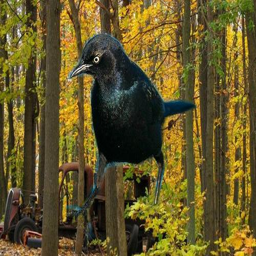

In [5]:
def show_hf_example(split: str, i: int):
    ex = waterbirds[split][i]
    print("label:", label_names[int(ex["label"])])
    print("place:", place_names[int(ex["place"])])
    print("bird: ", bird_names[int(ex["bird"])])
    return ex["image"].resize((256, 256))

show_hf_example("train", 200)

# Metadata

Before loading images into a model, look at the metadata. This is usually where many practical CV problems begin.

The key question is not only *how many images do we have?*, but also:

* What correlations are present in the dataset?
* What should be allowed to appear in both train and test?
* What should be balanced, or at least reported separately?

In [6]:
def metadata_from_hf_dataset_dict(dataset_dict) -> pd.DataFrame:
    rows = []
    for split in dataset_dict.keys():
        ds = dataset_dict[split]
        # Reading scalar columns does not require decoding all images.
        labels = ds["label"]
        places = ds["place"]
        birds = ds["bird"]
        for i, (label, place, bird) in enumerate(zip(labels, places, birds)):
            rows.append({
                "split": split,
                "index": i,
                "label": int(label),
                "label_name": label_names[int(label)],
                "place": int(place),
                "place_name": place_names[int(place)],
                "bird": int(bird),
                "bird_name": bird_names[int(bird)],
            })
    return pd.DataFrame(rows)

full_meta = metadata_from_hf_dataset_dict(waterbirds)
full_meta.head()

,split,index,label,label_name,place,place_name,bird,bird_name
0,train,0,1,waterbird,1,water,0,Black_footed_Albatross
1,train,1,1,waterbird,1,water,0,Black_footed_Albatross
2,train,2,1,waterbird,1,water,0,Black_footed_Albatross
3,train,3,1,waterbird,1,water,0,Black_footed_Albatross
4,train,4,1,waterbird,1,water,0,Black_footed_Albatross


In [7]:
full_meta.groupby("split").size()

,0
split,
test,5794
train,4795
validation,1199


In [8]:
# Class distribution in each split.
pd.crosstab(full_meta["split"], full_meta["label_name"], normalize="index").round(3)

label_name,landbird,waterbird
split,,
test,0.778,0.222
train,0.768,0.232
validation,0.778,0.222


In [9]:
# Background distribution conditional on class and split.
pd.crosstab(
    [full_meta["split"], full_meta["label_name"]],
    full_meta["place_name"],
    normalize="index"
).round(3)

place_name              land  water
split      label_name              
test       landbird    0.500  0.500
           waterbird   0.500  0.500
train      landbird    0.950  0.050
           waterbird   0.050  0.950
validation landbird    0.501  0.499
           waterbird   0.500  0.500

The training split is intentionally skewed: most waterbirds are on water, and most landbirds are on land.

This is the exact situation where average accuracy can be misleading: the easiest predictive feature in the training set is not necessarily the feature we wanted the model to learn.

---

# Exporting Waterbirds to ImageFolder

The HuggingFace dataset knows about `label`, `place`, and `bird`. `ImageFolder` does not know any of that metadata. It only sees this:

```text
root/class_name/image.jpg
```

So below we create a small `ImageFolder` version of the dataset:

```text
data/waterbirds_imagefolder/
  train/
    landbird/
    waterbird/
  validation/
    landbird/
    waterbird/
  test/
    landbird/
    waterbird/
```

This is not meant to be a general data pipeline yet. It is just enough to show how `ImageFolder` plugs into the same PyTorch training code we already used.

In [10]:
imagefolder_root = Path("data/waterbirds_imagefolder")

# Keep the class demonstration fast. Set a value to None to export the full split.
EXPORT_LIMITS = {
    "train": 1000,
    "validation": 300,
    "test": 300,
}

# For a real experiment, use the full dataset.
EXPORT_SEED = 0

In [11]:
def safe_filename_part(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "_-" else "_" for ch in s)


def export_split_to_imagefolder(split: str, max_items=None, seed: int = 0):
    ds = waterbirds[split]
    rng = np.random.default_rng(seed)

    indices = np.arange(len(ds))
    if max_items is not None and max_items < len(ds):
        indices = rng.choice(indices, size=max_items, replace=False)

    rows = []
    for original_i in tqdm(indices, desc=f"export {split}"):
        original_i = int(original_i)
        ex = ds[original_i]

        label_name = label_names[int(ex["label"])]
        place_name = place_names[int(ex["place"])]
        bird_name = bird_names[int(ex["bird"])]

        dst_dir = imagefolder_root / split / label_name
        dst_dir.mkdir(parents=True, exist_ok=True)

        filename = (
            f"{split}_{original_i:06d}"
            f"_place-{safe_filename_part(place_name)}"
            f"_bird-{safe_filename_part(bird_name)}.jpg"
        )
        dst_path = dst_dir / filename

        ex["image"].convert("RGB").save(dst_path, quality=95)

        rows.append({
            "split": split,
            "index": original_i,
            "path": str(dst_path),
            "label_name": label_name,
            "place_name": place_name,
            "bird_name": bird_name,
        })

    return rows

In [12]:
if imagefolder_root.exists():
    shutil.rmtree(imagefolder_root)

export_rows = []
for split in ["train", "validation", "test"]:
    export_rows.extend(
        export_split_to_imagefolder(
            split,
            max_items=EXPORT_LIMITS[split],
            seed=EXPORT_SEED,
        )
    )

export_meta = pd.DataFrame(export_rows)
export_meta.to_csv(imagefolder_root / "metadata.csv", index=False)
export_meta.head()

export train:   0%|          | 0/1000 [00:00<?, ?it/s]

export validation:   0%|          | 0/300 [00:00<?, ?it/s]

export test:   0%|          | 0/300 [00:00<?, ?it/s]

,split,index,path,label_name,place_name,bird_name
0,train,2323,data/waterbirds_imagefolder/train/landbird/tra...,landbird,land,Orchard_Oriole
1,train,203,data/waterbirds_imagefolder/train/landbird/tra...,landbird,land,Brewer_Blackbird
2,train,2677,data/waterbirds_imagefolder/train/landbird/tra...,landbird,land,Loggerhead_Shrike
3,train,107,data/waterbirds_imagefolder/train/waterbird/tr...,waterbird,water,Crested_Auklet
4,train,1918,data/waterbirds_imagefolder/train/landbird/tra...,landbird,land,Green_Kingfisher


In [13]:
!find data/waterbirds_imagefolder -maxdepth 2 -type d | sort

data/waterbirds_imagefolder
data/waterbirds_imagefolder/test
data/waterbirds_imagefolder/test/landbird
data/waterbirds_imagefolder/test/waterbird
data/waterbirds_imagefolder/train
data/waterbirds_imagefolder/train/landbird
data/waterbirds_imagefolder/train/waterbird
data/waterbirds_imagefolder/validation
data/waterbirds_imagefolder/validation/landbird
data/waterbirds_imagefolder/validation/waterbird


# ImageFolder

Now we can load each split with `ImageFolder`. Notice that we instantiate a separate dataset object for each split.

In [14]:
waterbird_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True),
    # For training an ImageNet-pretrained backbone (assignment 1), also add
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]).
])

train_dataset = ImageFolder(imagefolder_root / "train", transform=waterbird_transforms)
val_dataset = ImageFolder(imagefolder_root / "validation", transform=waterbird_transforms)
test_dataset = ImageFolder(imagefolder_root / "test", transform=waterbird_transforms)

train_dataset.classes, train_dataset.class_to_idx, len(train_dataset), len(val_dataset), len(test_dataset)

(['landbird', 'waterbird'], {'landbird': 0, 'waterbird': 1}, 1000, 300, 300)

class: landbird
path:  data/waterbirds_imagefolder/train/landbird/train_000080_place-land_bird-Groove_billed_Ani.jpg


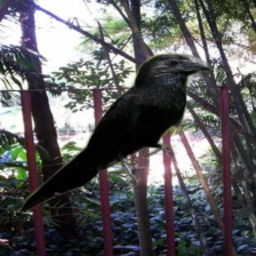

In [15]:
toPIL = transforms.ToPILImage()


def example(dataset, i: int):
    image, label = dataset[i]
    print("class:", dataset.classes[label])
    print("path: ", dataset.samples[i][0])
    return toPIL(image).resize((256, 256))

example(train_dataset, 0)

In [16]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
images, labels = next(iter(train_loader))

images.shape, labels

(torch.Size([16, 3, 224, 224]),
 tensor([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]))

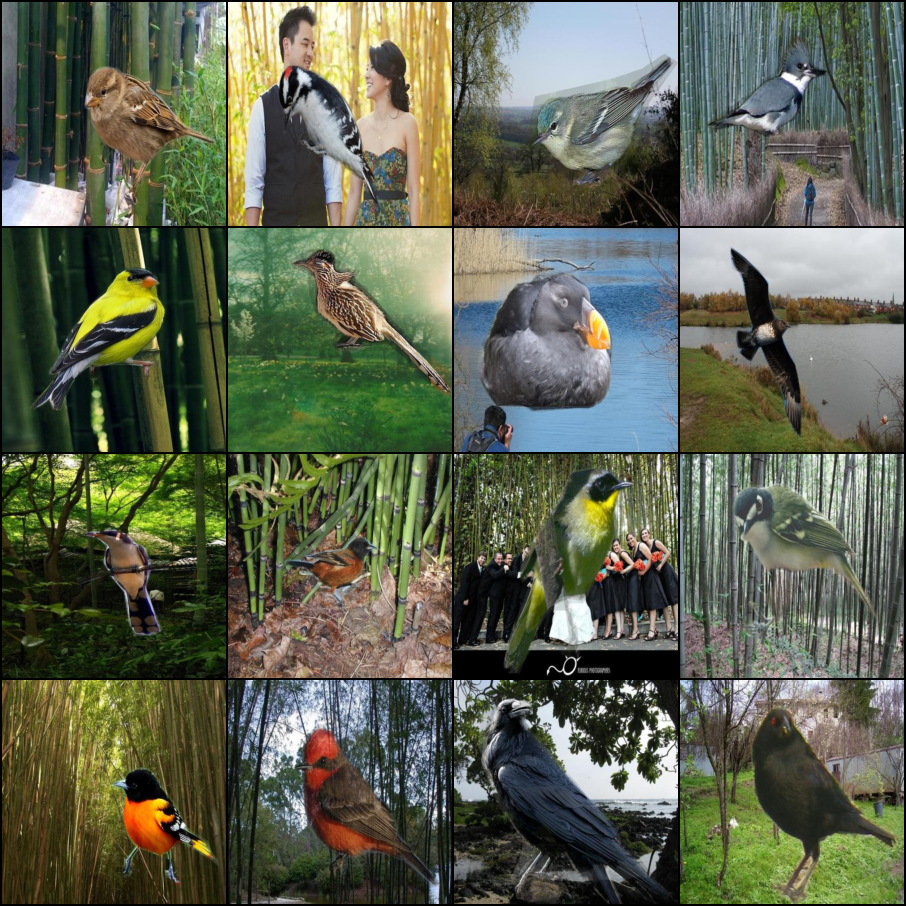

In [17]:
grid = make_grid(images[:16], nrow=4)
toPIL(grid)

`ImageFolder` gives us image tensors and class ids. It also stores paths:

In [18]:
train_dataset.samples[:5]

[('data/waterbirds_imagefolder/train/landbird/train_000080_place-land_bird-Groove_billed_Ani.jpg',
  0),
 ('data/waterbirds_imagefolder/train/landbird/train_000084_place-land_bird-Groove_billed_Ani.jpg',
  0),
 ('data/waterbirds_imagefolder/train/landbird/train_000090_place-land_bird-Groove_billed_Ani.jpg',
  0),
 ('data/waterbirds_imagefolder/train/landbird/train_000191_place-land_bird-Brewer_Blackbird.jpg',
  0),
 ('data/waterbirds_imagefolder/train/landbird/train_000195_place-land_bird-Brewer_Blackbird.jpg',
  0)]

The paths are useful because metadata is often encoded in filenames or stored in a separate CSV.

# Train/test split

A split is not an administrative detail. A split defines the question we are testing. Examples:

* **image-level split** --- can we classify more images from the same pool?
* **subject-level split** --- can we classify new people / patients / animals / objects?
* **video-level split** --- can we classify new videos, not just neighboring frames?
* **camera/site-level split** --- can we generalize to a new camera / hospital / source?
* **time split** --- can we generalize to the future?
* **domain split** --- can we generalize to a new style or domain?

Two honest splits can answer different questions.

## Stratification

Stratification means that we try to preserve some distribution across train and test.

The usual example is class stratification: if the whole dataset is 80% class A and 20% class B, we want train and test to be close to 80/20 as well.

But in real data we may also care about age, region, gender, camera, hospital, source, difficulty, and so on.

In [19]:
from sklearn.model_selection import train_test_split, StratifiedGroupKFold

indices = np.arange(len(train_dataset))
targets = np.array(train_dataset.targets)

inner_train_idx, inner_val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=0,
    stratify=targets,
)

pd.DataFrame({
    "all": pd.Series(targets).value_counts(normalize=True).sort_index(),
    "inner_train": pd.Series(targets[inner_train_idx]).value_counts(normalize=True).sort_index(),
    "inner_val": pd.Series(targets[inner_val_idx]).value_counts(normalize=True).sort_index(),
}).rename(index={v: k for k, v in train_dataset.class_to_idx.items()}).round(3)

,all,inner_train,inner_val
landbird,0.771,0.771,0.77
waterbird,0.229,0.229,0.23


### Stratifying on metadata, not only the label

Class stratification keeps the *label* proportions stable, but it lets other distributions drift. In Waterbirds the variable we actually care about is the background (`place`): it is the source of the shortcut. If we stratify on the label alone, the water/land mix inside each split can still move around.

We can stratify on a **composite key** instead --- combine the label with the metadata we want to preserve, and ask `train_test_split` to keep that *joint* distribution stable.

In [20]:
import re

def place_from_path(path: str) -> str:
    # exported filenames look like: train_000123_place-water_bird-...jpg
    match = re.search(r"_place-(.+?)_bird-", path)
    return match.group(1) if match else "unknown"

places = np.array([place_from_path(path) for path, _ in train_dataset.samples])
label_of = np.array([train_dataset.classes[t] for t in targets])

# composite stratification key: label x place
strata = np.array([f"{label} | {place}" for label, place in zip(label_of, places)])

meta_train_idx, meta_val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=0,
    stratify=strata,
)

# the joint (label, place) distribution is preserved in both parts
pd.DataFrame({
    "all": pd.Series(strata).value_counts(normalize=True).sort_index(),
    "inner_train": pd.Series(strata[meta_train_idx]).value_counts(normalize=True).sort_index(),
    "inner_val": pd.Series(strata[meta_val_idx]).value_counts(normalize=True).sort_index(),
}).round(3)

,all,inner_train,inner_val
landbird | land,0.723,0.722,0.725
landbird | water,0.048,0.048,0.050
waterbird | land,0.008,0.009,0.005
waterbird | water,0.221,0.221,0.220


### How far to push stratification

Every metadata field you add multiplies the number of strata: `label (2) × place (2)` gives 4 strata, and `label (2) × place (2) × age (3)` gives 12.

`train_test_split` needs at least two samples per stratum, so rare combinations make stratification unstable or impossible. A practical rule:

1. Stratify on the label and on the few metadata fields that matter most (here: the variable behind the shortcut).
2. Merge or drop strata that are too small to split on.
3. Report the remaining rare groups separately instead of forcing them into the split.

### When stratification is not the goal

Stratification tries to make the test set *look like* the training set. That is the right default when the training distribution is also the deployment distribution --- but not always.

Waterbirds is a deliberate counter-example. Its **training** set is skewed (most waterbirds on water, most landbirds on land), but its **test** set is *balanced*: all four `(type, place)` combinations appear about equally (see the per-split crosstab above). It was built this way on purpose, so that average test accuracy cannot be inflated by the background shortcut.

So there are two different choices for the test distribution:

* **Stratified / representative test** --- matches the training (deployment) mix.
  * *Pro:* the average metric is an unbiased estimate of field performance, and common groups get tight estimates.
  * *Con:* rare-but-important groups are under-represented, so the average hides their failures; if training carries a spurious correlation, a matching test inherits it and a shortcut model still looks good.
* **Balanced test** --- equal weight to each group, regardless of how rare it is in the wild.
  * *Pro:* every group counts equally, so worst-group failures surface, and it directly probes whether the model leans on the shortcut.
  * *Con:* the average no longer reflects deployment frequencies, so "test accuracy" is not an estimate of field performance; rare groups also need enough examples, which may mean collecting them.

Neither is universally correct. Decide what the test number should *mean* first --- representativeness, or equal coverage of groups --- then choose the test distribution to match.

Whether we match the training distribution or deliberately balance it, stratification on its own is still not enough --- even a perfectly stratified (or balanced) split can be a bad split.

## Subject leakage

A class-balanced or well-stratified split can still be wrong if the *unit* of the split is wrong. Suppose we have 5 photos of each person. If we put 4 photos of Alice in train and 1 photo of Alice in test, we may get excellent test accuracy --- but we are not testing generalization to new people, we are testing recognition of already-seen people.

In Waterbirds the natural "subject" is the **bird species**, not the photo. The dataset is built from images of specific species (the `bird` metadata we loaded), with many images per species and several species per genus. A random image-level split puts the same species --- and certainly the same genus --- on both sides, so a high score may mean *we recognized this kind of bird*, not *we learned land vs water*. If the question is generalization to unseen birds, no genus should appear in both train and test.

Let's simulate the general problem with a metadata table.

In [21]:
def make_fake_people_table(n_subjects=120, photos_per_subject=5, seed=0):
    rng = np.random.default_rng(seed)

    subject_ids = np.arange(n_subjects)
    label_by_subject = rng.choice(["class_0", "class_1"], size=n_subjects, p=[0.55, 0.45])
    region_by_subject = rng.choice(["north", "south", "east", "west"], size=n_subjects, p=[0.20, 0.35, 0.25, 0.20])
    age_by_subject = rng.choice(["child", "adult", "senior"], size=n_subjects, p=[0.15, 0.70, 0.15])

    rows = []
    for sid in subject_ids:
        for photo_id in range(photos_per_subject):
            rows.append({
                "subject_id": int(sid),
                "photo_id": photo_id,
                "label": label_by_subject[sid],
                "region": region_by_subject[sid],
                "age": age_by_subject[sid],
                "path": f"person_{sid:03d}/photo_{photo_id}.jpg",
            })
    return pd.DataFrame(rows)

people = make_fake_people_table()
people.head(10)

,subject_id,photo_id,label,region,age,path
0,0,0,class_1,south,adult,person_000/photo_0.jpg
1,0,1,class_1,south,adult,person_000/photo_1.jpg
2,0,2,class_1,south,adult,person_000/photo_2.jpg
3,0,3,class_1,south,adult,person_000/photo_3.jpg
4,0,4,class_1,south,adult,person_000/photo_4.jpg
5,1,0,class_0,south,senior,person_001/photo_0.jpg
6,1,1,class_0,south,senior,person_001/photo_1.jpg
7,1,2,class_0,south,senior,person_001/photo_2.jpg
8,1,3,class_0,south,senior,person_001/photo_3.jpg
9,1,4,class_0,south,senior,person_001/photo_4.jpg


In [22]:
def split_report(table, train_idx, test_idx, label_col="label", group_col="subject_id"):
    train_subjects = set(table.iloc[train_idx][group_col])
    test_subjects = set(table.iloc[test_idx][group_col])
    leaked = train_subjects & test_subjects

    return pd.Series({
        "train_size": len(train_idx),
        "test_size": len(test_idx),
        "train_subjects": len(train_subjects),
        "test_subjects": len(test_subjects),
        "leaked_subjects": len(leaked),
        "train_class_1": (table.iloc[train_idx][label_col] == "class_1").mean(),
        "test_class_1": (table.iloc[test_idx][label_col] == "class_1").mean(),
    })

idx = np.arange(len(people))

# This split is class-stratified, but it ignores subjects.
strat_train_idx, strat_test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=0,
    stratify=people["label"],
)

split_report(people, strat_train_idx, strat_test_idx)

,0
train_size,480.000000
test_size,120.000000
train_subjects,120.000000
test_subjects,81.000000
leaked_subjects,81.000000
train_class_1,0.508333
test_class_1,0.508333


In [23]:
# Now keep subjects non-overlapping and try to preserve class distribution.
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

group_train_idx, group_test_idx = next(
    sgkf.split(
        X=np.zeros((len(people), 1)),
        y=people["label"],
        groups=people["subject_id"],
    )
)

split_report(people, group_train_idx, group_test_idx)

,0
train_size,480.000000
test_size,120.000000
train_subjects,96.000000
test_subjects,24.000000
leaked_subjects,0.000000
train_class_1,0.510417
test_class_1,0.500000


The same `StratifiedGroupKFold` call solves the Waterbirds version: pass `groups=<bird genus>` instead of `subject_id`, and no genus can land in both train and test.

The order of priorities is important:

1. First prevent leakage.
2. Then stratify as well as possible under the no-leakage constraint.
3. Then report important slices separately.

If subject identity can leak, a class-stratified image split is usually not enough.

# Class imbalance

Leakage and stratification are about **evaluation design**.

Class imbalance is a different practical problem: one class may have many more training examples than another.

If we train with the usual unweighted loss, the model can often improve the average loss mostly by doing well on the majority class.

Two simple first-line tools are:

* **loss weighting** --- mistakes on rare classes receive larger loss;
* **oversampling / duplication** --- rare-class examples are sampled more often during training.

These tools change the **training pressure**. They do not create new information, and they do not fix leakage or shortcuts.

Important rule: balance the *training* process if needed, but do not silently balance the validation/test set unless that is the evaluation question.

In [24]:
def class_count_table(targets, class_names):
    targets = np.asarray(targets)
    counts = np.bincount(targets, minlength=len(class_names))
    total = counts.sum()
    return pd.DataFrame({
        "class": class_names,
        "count": counts,
        "fraction": counts / total,
    })


class_names = train_dataset.classes
targets_np = np.array(train_dataset.targets)

class_count_table(targets_np, class_names)

,class,count,fraction
0,landbird,771,0.771
1,waterbird,229,0.229


Waterbirds itself is mainly a shortcut-correlation example, not a pure class-imbalance example.

For demonstration, let us artificially create an imbalanced training subset: keep all `landbird` examples, but keep only a fraction of `waterbird` examples.


In [25]:
def make_imbalanced_subset_indices(targets, keep_fraction_by_class, seed=0):
    rng = np.random.default_rng(seed)
    kept = []

    for class_id, keep_fraction in keep_fraction_by_class.items():
        class_indices = np.flatnonzero(targets == class_id)
        n_keep = max(1, int(round(len(class_indices) * keep_fraction)))
        kept.extend(rng.choice(class_indices, size=n_keep, replace=False))

    kept = np.array(kept)
    rng.shuffle(kept)
    return kept


landbird_id = train_dataset.class_to_idx["landbird"]
waterbird_id = train_dataset.class_to_idx["waterbird"]

imbalanced_idx = make_imbalanced_subset_indices(
    targets_np,
    keep_fraction_by_class={
        landbird_id: 1.0,
        waterbird_id: 0.2,
    },
    seed=0,
)

imbalanced_train_dataset = Subset(train_dataset, imbalanced_idx)
imbalanced_targets = targets_np[imbalanced_idx]

pd.concat(
    {
        "original_train": class_count_table(targets_np, class_names).set_index("class"),
        "imbalanced_train": class_count_table(imbalanced_targets, class_names).set_index("class"),
    },
    axis=1,
).round(3)

original_train          imbalanced_train         
                   count fraction            count fraction
class                                                      
landbird             771    0.771              771    0.944
waterbird            229    0.229               46    0.056

## Approach 1: class weights in the loss

For classification with `CrossEntropyLoss`, we can provide a vector of class weights.

A common first approximation is inverse frequency: `class_weight[c] ∝ 1 / number_of_training_examples_in_class_c`. This means that an error on a rare class contributes more to the loss.

In a real training loop, the weights must be moved to the same device as the model and batch tensors.

In [26]:
counts = np.bincount(imbalanced_targets, minlength=len(class_names))
inverse_frequency = 1.0 / np.maximum(counts, 1)

# Normalization is not mathematically essential, but keeps the average scale of the loss reasonable.
loss_weights = inverse_frequency / inverse_frequency.mean()
loss_weights = torch.tensor(loss_weights, dtype=torch.float32)

pd.DataFrame({
    "class": class_names,
    "count": counts,
    "loss_weight": loss_weights.numpy(),
}).round(3)

,class,count,loss_weight
0,landbird,771,0.113
1,waterbird,46,1.887


In [27]:
# Example usage inside a training loop:
#
# device = "cuda" if torch.cuda.is_available() else "cpu"
# model = model.to(device)
# loss_fn = torch.nn.CrossEntropyLoss(weight=loss_weights.to(device))
#
# logits = model(images.to(device))
# loss = loss_fn(logits, labels.to(device))


## Approach 2: oversampling / duplication

Another approach is to sample rare-class examples more often.

In PyTorch, `WeightedRandomSampler` can do this without physically copying files.

Conceptually, this is similar to duplicating minority-class examples in the training set.


In [28]:
sample_weights = torch.tensor(
    inverse_frequency[imbalanced_targets],
    dtype=torch.double,
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=torch.Generator().manual_seed(0),
)

# We can inspect one sampled epoch without loading the images.
sampled_local_indices = np.array(list(iter(sampler)))
sampled_targets = imbalanced_targets[sampled_local_indices]

pd.concat(
    {
        "imbalanced_train": class_count_table(imbalanced_targets, class_names).set_index("class"),
        "one_weighted_sampled_epoch": class_count_table(sampled_targets, class_names).set_index("class"),
    },
    axis=1,
).round(3)

imbalanced_train          one_weighted_sampled_epoch         
                     count fraction                      count fraction
class                                                                  
landbird               771    0.944                        426    0.521
waterbird               46    0.056                        391    0.479

In [29]:
# Example DataLoader:
#
# imbalanced_loader = DataLoader(
#     imbalanced_train_dataset,
#     batch_size=32,
#     sampler=sampler,   # use sampler instead of shuffle=True
#     num_workers=2,
# )


We can also make duplication explicit by creating a list of indices where minority-class examples appear more than once.

This is sometimes useful pedagogically, but in real PyTorch code a sampler is usually cleaner.


In [30]:
def make_balanced_duplicate_indices(targets, seed=0):
    rng = np.random.default_rng(seed)
    counts = np.bincount(targets)
    max_count = counts.max()

    duplicated = []
    for class_id in range(len(counts)):
        class_indices = np.flatnonzero(targets == class_id)
        duplicated.extend(
            rng.choice(class_indices, size=max_count, replace=True)
        )

    duplicated = np.array(duplicated)
    rng.shuffle(duplicated)
    return duplicated


duplicated_local_idx = make_balanced_duplicate_indices(imbalanced_targets, seed=0)

# These indices are local indices inside imbalanced_train_dataset.
duplicated_train_dataset = Subset(imbalanced_train_dataset, duplicated_local_idx)
duplicated_targets = imbalanced_targets[duplicated_local_idx]

pd.concat(
    {
        "imbalanced_train": class_count_table(imbalanced_targets, class_names).set_index("class"),
        "duplicated_train": class_count_table(duplicated_targets, class_names).set_index("class"),
    },
    axis=1,
).round(3)

imbalanced_train          duplicated_train         
                     count fraction            count fraction
class                                                        
landbird               771    0.944              771      0.5
waterbird               46    0.056              771      0.5

## Balancing groups, not just classes

Class weighting and oversampling equalize the *class* counts, but they say nothing about *which kind* of each class the model sees. In Waterbirds, even after class balancing almost every waterbird is still on water --- so the background stays the easiest feature and the shortcut survives.

The fix mirrors the stratification idea: define a **group** as `(label, metadata)` --- here `label × place` --- and balance the *groups* instead of the classes. Rare groups like *waterbird on land* and *landbird on water* then get upweighted. This is the training-side counterpart of the worst-group accuracy we look at later.

The same two tools work, just keyed on the group instead of the class: inverse-group-frequency loss weights, or a `WeightedRandomSampler` whose per-sample weight is `1 / group_count`.

In [31]:
# group = (class, place) for the imbalanced training subset
# (places was parsed from the filenames in the stratification section)
imbalanced_places = places[imbalanced_idx]
imbalanced_groups = np.array([
    f"{class_names[t]} | {place}"
    for t, place in zip(imbalanced_targets, imbalanced_places)
])

group_names, group_codes = np.unique(imbalanced_groups, return_inverse=True)
group_counts = np.bincount(group_codes)

# per-sample weight inversely proportional to its group's size
group_sample_weights = torch.tensor((1.0 / group_counts)[group_codes], dtype=torch.double)

group_sampler = WeightedRandomSampler(
    weights=group_sample_weights,
    num_samples=len(group_sample_weights),
    replacement=True,
    generator=torch.Generator().manual_seed(0),
)
group_sampled_local_idx = np.array(list(iter(group_sampler)))


def group_fraction(local_idx):
    return pd.Series(imbalanced_groups[local_idx]).value_counts(normalize=True).sort_index()

# class balancing equalizes the two classes; group balancing equalizes the four (class x place) groups
pd.DataFrame({
    "imbalanced_train": group_fraction(np.arange(len(imbalanced_groups))),
    "class_balanced_epoch": group_fraction(sampled_local_indices),
    "group_balanced_epoch": group_fraction(group_sampled_local_idx),
}).round(3)

,imbalanced_train,class_balanced_epoch,group_balanced_epoch
landbird | land,0.885,0.492,0.241
landbird | water,0.059,0.029,0.252
waterbird | land,0.001,0.009,0.255
waterbird | water,0.055,0.470,0.252


Group balancing is stronger medicine, with stronger side effects:

* it needs group labels (metadata) at training time;
* rare groups get duplicated heavily, so the model may memorize a few examples;
* it reweights existing data --- it does not create the missing combinations.

If *waterbird on land* has only a handful of examples, sampling them 100× does not turn them into 100 real examples --- collecting or constructing the missing groups is better than reweighting alone. Balancing groups changes the training *pressure*; worst-group accuracy on a fair test set tells you whether it actually helped.

Class weighting and oversampling are useful, but they are not magic.

* **class weighting** changes how much each mistake matters;
* **oversampling / duplication** changes how often examples appear in batches;
* **more data** changes what the model can actually learn.

If the minority class is small and all its examples come from the same source, oversampling may simply make the model memorize that source.

If the minority class is rare in deployment but important, we may want a representative average metric *plus* a separate rare-class or worst-group metric.

Do not confuse the **training distribution** (what pressure we use to fit the model) with the **test distribution** (what question we want the final number to answer).

# Shortcuts

A shortcut is a feature that is predictive in the dataset, but is not the concept we wanted the model to learn. Examples:

* a cat-vs-dog classifier learns indoor/outdoor background;
* a medical classifier learns a hospital marker or scanner style;
* a product classifier learns a watermark or website layout;
* a bird classifier learns water/land background;
* a face classifier learns camera/source instead of the intended attribute.

The model is not cheating. The dataset allowed the shortcut.

## Waterbirds shortcut baseline

Before training a CNN, let's try an intentionally stupid rule: if the background is water, predict `waterbird`; if it is land, predict `landbird`.

This rule looks at the background, not the bird.

In [32]:
full_meta = full_meta.copy()
full_meta["background_prediction"] = np.where(
    full_meta["place_name"] == "water",
    "waterbird",
    "landbird",
)
full_meta["background_correct"] = full_meta["background_prediction"] == full_meta["label_name"]

rows = []
for split, df in full_meta.groupby("split"):
    group_acc = df.groupby(["label_name", "place_name"])["background_correct"].mean()
    rows.append({
        "split": split,
        "average_accuracy": df["background_correct"].mean(),
        "worst_group_accuracy": group_acc.min(),
    })

pd.DataFrame(rows).round(3)

,split,average_accuracy,worst_group_accuracy
0,test,0.50,0.0
1,train,0.95,0.0
2,validation,0.50,0.0


In [33]:
# Which groups does the shortcut rule fail on?
(
    full_meta
    .groupby(["split", "label_name", "place_name"])["background_correct"]
    .mean()
    .rename("accuracy")
    .reset_index()
    .pivot_table(index=["label_name", "place_name"], columns="split", values="accuracy")
    .round(3)
)

split                  test  train  validation
label_name place_name                         
landbird   land         1.0    1.0         1.0
           water        0.0    0.0         0.0
waterbird  land         0.0    0.0         0.0
           water        1.0    1.0         1.0

This is why a single average accuracy can be dangerous.

If the validation set has the same shortcut correlation as the training set, the shortcut can look like a good classifier. If the validation/test set contains rare combinations, the same rule fails badly on those groups.

In [34]:
# A random validation split made only from the skewed training data can still make the shortcut look good.
skewed_train_meta = full_meta[full_meta["split"] == "train"].reset_index(drop=True)
idx = np.arange(len(skewed_train_meta))

_, fake_val_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=0,
    stratify=skewed_train_meta["label_name"],
)

fake_val = skewed_train_meta.iloc[fake_val_idx]

pd.Series({
    "fake_validation_average_accuracy": fake_val["background_correct"].mean(),
    "fake_validation_worst_group_accuracy": fake_val.groupby(["label_name", "place_name"])["background_correct"].mean().min(),
}).round(3)

,0
fake_validation_average_accuracy,0.95
fake_validation_worst_group_accuracy,0.00


The fake validation set is not malicious. It is a perfectly normal random split from a biased pool.

But it answers the wrong question if deployment may contain waterbirds on land or landbirds on water.

# How to detect shortcuts

Useful practical checks:

1. Look at high-confidence mistakes.
2. Look at very easy successes, not only failures.
3. Report accuracy by class and by important metadata slices.
4. Compare average accuracy with worst-group accuracy.
5. Try stupid baselines: background-only, source-only, metadata-only, low-resolution.
6. Check near-duplicates between train and test.
7. Ask whether the split unit is correct: image, subject, video, site, time, domain.

A stress test is not necessarily the final metric. It is a way to generate suspicion.

# How to protect against shortcuts

Before advanced methods, the most useful protections are simple:

1. **Split correctly.** If subject leakage is possible, split by subject. If site leakage is possible, split by site. If time matters, use a time split.
2. **Collect or construct missing combinations** --- for example, waterbirds on land and landbirds on water.
3. **Report slices.** Do not report only one accuracy number.
4. **Remove obvious artifacts** --- borders, watermarks, scanner labels, source-specific formatting.
5. **Use augmentation only when it represents a valid invariance.** Horizontal flip is not automatically safe; rotation is not automatically safe.
6. **Handle class imbalance in the training process if needed.** Class weights and oversampling can help the model pay attention to rare classes, but they do not fix leakage, missing groups, or shortcuts.
7. **Keep a final test set untouched.** Use it once, after the model/protocol is fixed.

---

# Assignment [5]

## Due by 8:00, 25.06.2026

## 1. Waterbirds [2]

Using the techniques we have seen so far, train a resnet18 model (you may use an ImageNet-pretrained backbone) on the Waterbirds dataset. Respect the train/validation/test split and use the test set only once, for the final report.

Report both **average accuracy** and **worst-group accuracy** over the four `(label, place)` groups, and try to make the **worst-group** accuracy as high as possible --- a high average alone can simply mean the model learned the background shortcut.

In [35]:
from torchvision.models import resnet18, ResNet18_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Training transform: mild, label-preserving augmentation (horizontal flip is a safe
# invariance for bird photos) plus ImageNet normalization for the pretrained backbone.
wb_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# Validation/test transform: no augmentation, so evaluation is deterministic.
wb_eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

wb_train_dataset = ImageFolder(imagefolder_root / "train", transform=wb_train_transforms)
wb_val_dataset = ImageFolder(imagefolder_root / "validation", transform=wb_eval_transforms)
wb_test_dataset = ImageFolder(imagefolder_root / "test", transform=wb_eval_transforms)

wb_train_dataset.classes, len(wb_train_dataset), len(wb_val_dataset), len(wb_test_dataset)

(['landbird', 'waterbird'], 1000, 300, 300)

In [36]:
def dataset_group_labels(dataset):
    """(label, place) group string for every sample in an ImageFolder dataset,
    using the same `place_from_path` parser defined in the stratification section."""
    labels = np.array([dataset.classes[target] for _, target in dataset.samples])
    places = np.array([place_from_path(path) for path, _ in dataset.samples])
    return np.array([f"{label} | {place}" for label, place in zip(labels, places)])


wb_train_groups = dataset_group_labels(wb_train_dataset)
wb_val_groups = dataset_group_labels(wb_val_dataset)
wb_test_groups = dataset_group_labels(wb_test_dataset)

pd.Series(wb_train_groups).value_counts()

,count
landbird | land,723
waterbird | water,221
landbird | water,48
waterbird | land,8


In [38]:
# Group-balance the training batches: per-sample weight inversely proportional to the
# size of its (label, place) group. This is the "Balancing groups" idea from above,
# applied here so training pressure does not reward the background shortcut.
train_group_names, train_group_codes = np.unique(wb_train_groups, return_inverse=True)
train_group_counts = np.bincount(train_group_codes)
train_group_sample_weights = torch.tensor(
    (1.0 / train_group_counts)[train_group_codes], dtype=torch.double
)

wb_train_sampler = WeightedRandomSampler(
    weights=train_group_sample_weights,
    num_samples=len(train_group_sample_weights),
    replacement=True,
    generator=torch.Generator().manual_seed(0),
)

BATCH_SIZE = 32

# Training uses the group-balanced sampler instead of shuffle=True.
wb_train_loader = DataLoader(
    wb_train_dataset, batch_size=BATCH_SIZE, sampler=wb_train_sampler, num_workers=2
)
# Validation/test stay in natural order and are never balanced or reweighted.
wb_val_loader = DataLoader(wb_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
wb_test_loader = DataLoader(wb_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [39]:
wb_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
wb_model.fc = torch.nn.Linear(wb_model.fc.in_features, len(wb_train_dataset.classes))
wb_model = wb_model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


In [41]:
@torch.no_grad()
def evaluate_average_and_worst_group(model, loader, group_labels):
    """Average accuracy and worst-group accuracy over `group_labels` (must be in the
    same order as `loader` iterates, so only use this with shuffle=False loaders)."""
    model.eval()
    all_correct = []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        all_correct.append((preds == labels).cpu())
    correct = torch.cat(all_correct).numpy()

    group_labels = np.asarray(group_labels)
    assert len(correct) == len(group_labels)

    average_accuracy = correct.mean()
    per_group_accuracy = pd.Series(correct, index=group_labels).groupby(level=0).mean()
    worst_group_accuracy = per_group_accuracy.min()

    return average_accuracy, worst_group_accuracy, per_group_accuracy

def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    running_loss = 0.0
    n_examples = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        n_examples += images.size(0)
    return running_loss / n_examples

In [42]:
NUM_EPOCHS = 10
LR = 1e-4

optimizer = torch.optim.Adam(wb_model.parameters(), lr=LR)
loss_fn = torch.nn.CrossEntropyLoss()

best_val_worst_group_acc = -1.0
best_state_dict = None
history = []

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(wb_model, wb_train_loader, optimizer, loss_fn)
    val_avg_acc, val_worst_acc, val_per_group_acc = evaluate_average_and_worst_group(
        wb_model, wb_val_loader, wb_val_groups
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_average_accuracy": val_avg_acc,
        "val_worst_group_accuracy": val_worst_acc,
    })
    print(
        f"epoch {epoch:02d} | train_loss={train_loss:.4f} "
        f"| val_avg_acc={val_avg_acc:.3f} | val_worst_group_acc={val_worst_acc:.3f}"
    )

    # Model selection on worst-group accuracy (not average accuracy or loss): this is
    # the quantity we actually care about, and selecting on it avoids rewarding the
    # background shortcut during checkpoint selection too.
    if val_worst_acc > best_val_worst_group_acc:
        best_val_worst_group_acc = val_worst_acc
        best_state_dict = {k: v.detach().cpu().clone() for k, v in wb_model.state_dict().items()}

history_df = pd.DataFrame(history)
history_df

epoch 00 | train_loss=0.1815 | val_avg_acc=0.753 | val_worst_group_acc=0.530
epoch 01 | train_loss=0.1025 | val_avg_acc=0.800 | val_worst_group_acc=0.290
epoch 02 | train_loss=0.0278 | val_avg_acc=0.783 | val_worst_group_acc=0.323
epoch 03 | train_loss=0.0093 | val_avg_acc=0.777 | val_worst_group_acc=0.323
epoch 04 | train_loss=0.0157 | val_avg_acc=0.780 | val_worst_group_acc=0.387
epoch 05 | train_loss=0.0050 | val_avg_acc=0.760 | val_worst_group_acc=0.323
epoch 06 | train_loss=0.0075 | val_avg_acc=0.817 | val_worst_group_acc=0.387
epoch 07 | train_loss=0.0041 | val_avg_acc=0.800 | val_worst_group_acc=0.387
epoch 08 | train_loss=0.0102 | val_avg_acc=0.807 | val_worst_group_acc=0.161
epoch 09 | train_loss=0.0384 | val_avg_acc=0.753 | val_worst_group_acc=0.194


,epoch,train_loss,val_average_accuracy,val_worst_group_accuracy
0,0,0.181535,0.753333,0.530435
1,1,0.102520,0.800000,0.290323
2,2,0.027798,0.783333,0.322581
3,3,0.009304,0.776667,0.322581
4,4,0.015710,0.780000,0.387097
5,5,0.005012,0.760000,0.322581
6,6,0.007506,0.816667,0.387097
7,7,0.004100,0.800000,0.387097
8,8,0.010243,0.806667,0.161290
9,9,0.038434,0.753333,0.193548


In [43]:
# The test set is used exactly once here, with the checkpoint chosen on
# validation worst-group accuracy above.
wb_model.load_state_dict(best_state_dict)

test_avg_acc, test_worst_acc, test_per_group_acc = evaluate_average_and_worst_group(
    wb_model, wb_test_loader, wb_test_groups
)

print(f"test average accuracy:     {test_avg_acc:.3f}")
print(f"test worst-group accuracy: {test_worst_acc:.3f}")
test_per_group_acc.rename("accuracy").to_frame().round(3)

test average accuracy:     0.823
test worst-group accuracy: 0.636


,accuracy
landbird | land,0.969
landbird | water,0.636
waterbird | land,0.853
waterbird | water,0.941


## 2. Experimental protocol [3]

Choose one of the following tasks, or propose your own CV task:

* animal species classifier;
* medical image classifier;
* traffic sign classifier;
* product classifier;
* face attribute classifier;
* satellite image classifier;
* factory defect detector.

Write an evaluation protocol. It should answer:

1. What is the real deployment distribution?
2. What is the sample: image, crop, frame, subject, object, patient, site?
3. What must not leak between train and test?
4. What should be stratified?
5. What metric or metrics should be reported?
6. What slices should be reported separately?
7. Is class imbalance expected? If yes, would you use class weighting, oversampling, duplication, or more data?
8. What shortcut might the model learn?
9. What simple stress test or stupid baseline would you try?
10. Which augmentations are valid, and which are dangerous?
11. What result would make you distrust the model?

### Chosen task (Medical Image Classifier): **dermoscopy classifier**, *melanoma* vs. *benign mole (nevus)*

**Setting.** A dermatologist (or a GP with a dermatoscope) photographs a pigmented skin lesion through a dermatoscope. The model outputs a probability that the lesion is melanoma. It is a **decision-support tool**: a high score means "biopsy or refer this lesion"; a low score means "routine follow-up". It does not replace the doctor.

**Labels.** Melanoma is confirmed by histopathology (biopsy). Benign moles are confirmed either by histopathology (if they were excised) or by expert consensus / stable follow-up over time.

**What a realistic dataset looks like** (e.g. the public ISIC archive / ISIC 2020 challenge, HAM10000). Each image comes with metadata such as `patient_id`, `lesion_id`, clinic / hospital, dermatoscope model, anatomical site, patient age and sex, and sometimes skin type. One patient has several lesions, and one lesion can have several images. The protocol below is built around these facts.

**Why the errors are not symmetric.** This asymmetry drives most of the decisions below:

* **False negative** (melanoma called benign): the cancer is not biopsied, keeps growing and can metastasise. This is the *dangerous* error.
* **False positive** (benign mole called melanoma): an unnecessary biopsy, a scar, cost and patient anxiety. Bad, but not life-threatening. Too many false positives still make the tool useless, because doctors will stop trusting it.

### Evaluation protocol: data, splits and metrics (questions 1–6)

**1. What is the real deployment distribution?**

The images the model will see after release are:

* **new patients**, never seen in training;
* often from **new clinics and new devices**: different dermatoscope brands, polarised vs. non-polarised light, contact vs. non-contact, phone-attached dermatoscopes, different resolutions and colour profiles;
* at a **realistic melanoma rate**, which is low. In the ISIC 2020 dataset only about 1.8% of images are melanoma (584 of ~33k). In a clinic the rate depends on which lesions doctors decide to photograph, but it is a small minority;
* from a **wider population** than most public datasets. Those mostly come from light-skinned patients in Europe, the US and Australia, while a deployed tool may see darker skin types and more *acral* lesions (palms, soles, nails).

Consequence: the main test set should come from **held-out patients, ideally from held-out clinics/devices**, and keep the **natural melanoma rate**. Balancing the test set would make the tool look better than it will perform in practice (see question 5).

**2. What is the sample?**

The data has three levels: **patient → lesion → image(s)**.

* The model's *input* is one image.
* The *decision* is made per **lesion**: "should this mole be biopsied?". If a lesion has several images (different zoom, polarisation, follow-up visits), average the predicted probabilities over them and compute metrics per lesion. Otherwise a lesion with 5 images counts 5 times.
* The *independent unit* is the **patient**. Lesions of the same patient share skin tone, hair, age, body-site habits, the clinic and the device. They are not independent examples.

**3. What must not leak between train and test?**

* **Patients.** All images of one patient go to the same split. Example: if a patient's melanoma has 3 images in train and 1 in test, the model can just *recognise that lesion* (same shape, same skin, same hair) instead of recognising melanoma, and test accuracy is inflated.
* **Lesions and near-duplicates.** The same lesion photographed at different visits or zoom levels. Splitting by patient already covers this. When **merging several public datasets**, also check for duplicate images: the ISIC archive reuses images across challenge years, so image hashes or perceptual-hash matching are needed.
* **Clinics/devices, for the generalisation test.** For an honest "new clinic" estimate, a whole clinic (or device type) must be held out. A random patient split still lets the model learn each clinic's style.
* **Decisions based on the test set.** The decision threshold, the checkpoint, normalisation statistics and hyper-parameters are all chosen on **validation only**. The test set is used once, as in the Waterbirds training loop above.

Tool: `StratifiedGroupKFold(groups=patient_id)`, or `groups=clinic_id` for the leave-one-clinic-out variant.

**4. What should be stratified?**

* **The label (melanoma / benign)** first. Melanomas are so rare that a random split can leave a fold with only a handful of them, and then sensitivity can't be estimated.
* **The variables behind likely shortcuts and important slices:** clinic/device, skin type (if recorded), and anatomical site. In practice, stratify on a combined key such as `label × clinic` and group by `patient_id`.
* Very rare combinations (e.g. *acral melanoma on dark skin*) can't be forced into every fold. Report them separately and say that the numbers are based on very few cases.

**5. What metrics should be reported, and why?**

*Accuracy is **not** reported as the main metric.* With 2% melanoma, a model that always answers "benign" has **98% accuracy** and finds zero cancers.

| Metric | Meaning for this problem | Why it is reported |
|---|---|---|
| **Sensitivity** (recall of melanoma) = TP / (TP + FN) | Of all real melanomas, what fraction the tool flags. | **Primary metric.** A missed melanoma is the dangerous error. |
| **Specificity** = TN / (TN + FP) | Of all benign moles, what fraction the tool correctly leaves alone. | Low specificity means many unnecessary biopsies. |
| **Specificity at a fixed high sensitivity** (e.g. at 95% sensitivity) | "If we require the tool to catch 95% of melanomas, how many benign moles will it also send to biopsy?" | This is the actual operating point a clinic would use. The threshold is chosen on validation to reach the target sensitivity, then frozen for test. |
| **ROC AUC** | Probability that a random melanoma gets a higher score than a random benign mole. Threshold-free. | Standard in the field (the ISIC 2020 challenge metric), good for comparing models. It is insensitive to prevalence, so it is not enough on its own. |
| **PPV (precision)** and **PR AUC** | Of the lesions the tool flags, what fraction really are melanoma. | Shows the real workload at low prevalence (example below). |
| **Number needed to biopsy (NNB)** = 1 / PPV | How many lesions are biopsied to find one melanoma. | A number doctors already use, so the tool can be compared to current practice. |
| **Calibration** (reliability plot / ECE) | Does a predicted 30% really mean ~30% of such lesions are melanoma? | Doctors read the score as a risk, so it should mean what it says. |

**Worked example: why PPV matters at low prevalence.** 1000 lesions, 20 melanomas (2%). The model has 95% sensitivity and 90% specificity, which sounds excellent:

* melanomas found: 0.95 × 20 = **19** (1 missed);
* false alarms: 0.10 × 980 = **98** benign moles flagged;
* PPV = 19 / (19 + 98) ≈ **16%**, so NNB ≈ 6: about 6 biopsies per melanoma found.

This may or may not be acceptable compared with the clinic's current NNB. Sensitivity and AUC alone would never show it.

**Uncertainty.** With only tens of melanomas in the test set, sensitivity is very noisy: one extra miss out of 20 changes it by 5 percentage points. Report **95% confidence intervals** from a bootstrap that resamples **patients** (not images).

**6. What slices should be reported separately?**

For each slice report sensitivity and specificity at the frozen threshold, the number of melanomas in it, and the **worst-slice sensitivity**, the same idea as worst-group accuracy in Waterbirds.

* **Skin type** (Fitzpatrick I–II / III–IV / V–VI). Public data has very few dark-skin images, so this is where the model is most likely to fail silently.
* **Clinic / hospital** and **dermatoscope type** (polarised vs. non-polarised, brand, phone vs. professional device).
* **Anatomical site:** trunk, limbs, head/neck, and especially **acral** (palms, soles, nails). Acral melanoma looks different and is rare in training data.
* **Age group and sex.** Melanoma is more common in older patients, so the model may use "looks like older skin" as a cue.
* **Artifact presence:** ruler, ink/pen marks, hair, air bubbles, dark vignette corners (this links to the shortcuts in question 8).
* **Difficult benign lesions:** atypical/dysplastic nevi. These are the look-alikes, and specificity on them matters most.
* **Early vs. advanced melanoma** (in situ / thin vs. thick), if pathology data allows. Catching *early* melanoma is the clinical goal, and thick melanomas are the easy ones.

### Evaluation protocol: training, shortcuts and sanity checks (questions 7–11)

**7. Is class imbalance expected? What would you do?**

Yes, strongly: melanoma is about 2–10% of images, depending on the source. The options, in order of preference:

1. **More data (best).** Add real melanoma cases from other clinics or public sources (ISIC archive, HAM10000, etc.). This adds new *information*, not just new weight. Check for duplicates and patient overlap when merging (question 3).
2. **Class weighting in the loss** (e.g. `CrossEntropyLoss(weight=...)` with weight ∝ 1 / class frequency) or a **`WeightedRandomSampler`** for the training loader. Both stop the model from ignoring melanoma to minimise the average loss. I would start with class weighting because it does not repeat images. The sampler is fine too, as long as strong augmentation is used together with it.
3. **Plain duplication of melanoma images: avoid.** A few hundred melanomas repeated 20× are memorised, not learned (the notebook's "100× sampling ≠ 100 real examples").

Important details:

* Rebalance **only the training data.** Validation and test keep the natural prevalence, because the metrics must describe real use. If the natural test set has too few melanomas for stable estimates, add a *separate* melanoma-enriched test set and report it separately, clearly labelled.
* Weighting shifts the predicted probabilities upward, so the **decision threshold must be re-tuned on validation** (to the target sensitivity), and calibration must be checked.
* If a shortcut group is known (e.g. `label × ruler present`), use **group balancing** instead of just class balancing, as in the Waterbirds section.

**8. What shortcut might the model learn?**

Anything that is correlated with the label in the dataset but is *not* the lesion itself:

* **Rulers and scale markers.** Suspicious lesions are more often measured, so a ruler in the image correlates with melanoma.
* **Surgical ink / skin markings.** Doctors circle lesions they plan to excise with a marker pen, and those are more often melanoma. Published studies (e.g. Winkler et al., *JAMA Dermatology*, 2019) showed that such markings noticeably increased a commercial CNN's melanoma scores for benign lesions.
* **Clinic / device style.** If a specialist referral centre (many melanomas) uses one dermatoscope and a screening clinic (mostly benign) uses another, the model can learn "this colour profile / resolution / dark vignette = melanoma".
* **Patient traits:** older-looking skin, sun damage, and body site (e.g. back in men) are correlated with melanoma but don't diagnose the specific mole.
* **Skin tone.** If almost all training images come from light skin, "dark skin background" is out of distribution and the model's behaviour there is arbitrary.
* **Lesion size or zoom level.** Melanomas are often larger, which is partly a real clinical sign (the "D" in ABCDE). But if different devices zoom differently, size also encodes the device.

This is the Waterbirds problem again. The ruler or ink mark plays the role of the *water background*, and a high average accuracy can hide that the model looks at the ruler rather than at the mole.

**9. What simple stress test or stupid baseline would you try?**

* **"Always benign" baseline.** Gives ~98% accuracy and 0% sensitivity. It shows why accuracy is useless here and sets the floor for every metric.
* **Metadata-only model.** Logistic regression on `clinic, device, age, sex, body site, image resolution`, **without any pixels**. If its AUC is far above 0.5 (say 0.75), the dataset contains shortcuts the CNN can also use, like the notebook's background-only rule for Waterbirds.
* **Lesion-masked test.** Segment the lesion and cover it (e.g. inpaint with surrounding skin colour), then evaluate, or train on images where only the skin *around* the lesion is visible. A model that should look at the mole must drop to about AUC 0.5. If it stays high, it is using context.
* **Lesion-only crop.** Crop tightly around the lesion (removing rulers, corners, ink). Performance should stay about the same. A big drop means the context was doing the work.
* **Counterfactual artifact test.** Digitally add a ruler or a purple ink circle to *benign* images and check whether predictions flip to melanoma, and remove them from melanoma images where possible. A robust model barely changes.
* **Leave-one-clinic-out evaluation.** Train on all clinics except one, test on it, and repeat. Compare with the random patient split. A large gap means the model learned clinic style.
* **Simple handcrafted baseline.** Colour, asymmetry, border and size features (ABCD-like) + logistic regression. It shows how much the CNN actually adds over classical rules.

**10. Which augmentations are valid, and which are dangerous?**

The question for every augmentation: *does it produce an image that could really occur, with the same label?*

Valid (the label doesn't change):

* **Horizontal and vertical flips, 90° and arbitrary rotations.** A dermoscopic image is taken from above, and a mole has no "up". (This differs from chest X-rays, where left-right flips are dangerous because the heart is on one side.)
* **Small scale changes / zoom** and **random crops that keep the whole lesion** in view: they simulate different distance and zoom.
* **Mild brightness, contrast and small colour jitter:** they simulate different lighting and devices, and help against the device shortcut.
* **Mild blur / noise and hair simulation:** they simulate focus and real skin.
* **Adding rulers or ink marks to *both* classes:** this breaks the artifact shortcut instead of creating one.

Dangerous (they can change the label or create fake signals):

* **Strong hue / colour shifts.** Colour is a diagnostic feature: blue-white veil, several colours in one lesion, black/grey areas (the "C" in ABCDE). A strong hue shift can make a benign mole look malignant or hide a melanoma's colours. It can also fake an unrealistic skin tone.
* **Crops that cut off part of the lesion.** Border irregularity and asymmetry are key signs, and the malignant part may be only in one region of the mole. Cutting it off leaves an image labelled *melanoma* that shows only benign-looking tissue.
* **Elastic deformation, strong shear, strong aspect-ratio changes.** They change the lesion's shape and symmetry, which are exactly what the doctor evaluates.
* **Cutout / random erasing over the lesion:** it can erase the only malignant structure.
* **Heavy downscaling:** it destroys fine dermoscopic structures (dots, globules, streaks, pigment network).
* **MixUp / CutMix between lesions:** the result is a lesion that doesn't exist, with a blended label that has no clinical meaning. Use with great care, if at all.

**11. What result would make you distrust the model?**

* **Test performance that is too good**, e.g. AUC ≈ 0.99 or 100% sensitivity with high specificity. That is far above dermatologists and published models, so first suspect leakage (duplicates, the same patient in train and test).
* **A large drop from image-level to patient-level splitting**, or from random-patient to **leave-one-clinic-out** evaluation. The model learned patients or clinics, not melanoma.
* **The metadata-only or lesion-masked baseline performs well** (AUC clearly above 0.5). The information comes from outside the lesion.
* **Predictions flip when a ruler or ink mark is added** to a benign image.
* **High average sensitivity but a much lower worst-slice sensitivity**, e.g. 92% overall but 60% on dark skin or on acral lesions. This is the same "high average hides a failing group" pattern as in Waterbirds.
* **Saliency maps (e.g. Grad-CAM)** that highlight rulers, image corners, ink or hair instead of the lesion.
* **The threshold doesn't transfer:** 95% sensitivity on validation but much lower on test. The threshold or checkpoint was overfit to validation.
* **Poor calibration:** e.g. lesions scored "80% melanoma" turn out to be melanoma 20% of the time.
* **Very wide confidence intervals**, e.g. a slice result based on 3 melanomas. That is not a *bad* result, but it is not evidence either way, and should not be reported as if it were.